Realizado por:
 - Isabella Pérez C. - 2230603
 - Luz A. Carabali M. - 2230652
 - Nicolas Zapata O. - 2230303

Descargamos este paquete para hacer uso del dataset Auto MPG

In [ ]:
!pip install -U ucimlrepo

se importan las librerias

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV
from ucimlrepo import fetch_ucirepo, list_available_datasets

se observa que dataset hay y se mira en que posicion esta el Auto MPG para ahora si utilizarlo

In [ ]:
# check which datasets can be imported
from ucimlrepo import fetch_ucirepo, list_available_datasets
list_available_datasets()

-------------------------------------
The following datasets are available:
-------------------------------------
Dataset Name                                                                            ID    
------------                                                                            --    
Abalone                                                                                 1     
Adult                                                                                   2     
Annealing                                                                               3     
Audiology (Standardized)                                                                8     
Auto MPG                                                                                9     
Automobile                                                                              10    
Balance Scale                                                                           12    
Balloons                       

se selecciona el datadet auto Auto MPG

In [ ]:
auto_mpg = fetch_ucirepo(id=9)


se mira cuales son las columnas e informacion  que contiene el dataset

In [ ]:
# data (as pandas dataframes)
X = auto_mpg.data.features
y = auto_mpg.data.targets

# metadata
print(auto_mpg.metadata)

# variable information
print(auto_mpg.variables)

{'uci_id': 9, 'name': 'Auto MPG', 'repository_url': 'https://archive.ics.uci.edu/dataset/9/auto+mpg', 'data_url': 'https://archive.ics.uci.edu/static/public/9/data.csv', 'abstract': 'Revised from CMU StatLib library, data concerns city-cycle fuel consumption', 'area': 'Other', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 398, 'num_features': 7, 'feature_types': ['Real', 'Categorical', 'Integer'], 'demographics': [], 'target_col': ['mpg'], 'index_col': ['car_name'], 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1993, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5859H', 'creators': ['R. Quinlan'], 'intro_paper': None, 'additional_info': {'summary': 'This dataset is a slightly modified version of the dataset provided in the StatLib library.  In line with the use by Ross Quinlan (1993) in predicting the attribute "mpg", 8 of the original instances were removed because they had unknown values for th

Combinar X e y en un solo DataFrame

In [ ]:
df = X.copy()
df['mpg'] = y

In [ ]:
df.head()

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin,mpg
0,307.0,8,130.0,3504,12.0,70,1,18.0
1,350.0,8,165.0,3693,11.5,70,1,15.0
2,318.0,8,150.0,3436,11.0,70,1,18.0
3,304.0,8,150.0,3433,12.0,70,1,16.0
4,302.0,8,140.0,3449,10.5,70,1,17.0


# EDA

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   displacement  398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   horsepower    392 non-null    float64
 3   weight        398 non-null    int64  
 4   acceleration  398 non-null    float64
 5   model_year    398 non-null    int64  
 6   origin        398 non-null    int64  
 7   mpg           398 non-null    float64
dtypes: float64(4), int64(4)
memory usage: 25.0 KB


In [ ]:
df.shape

(398, 8)

In [ ]:
df.dtypes

,0
displacement,float64
cylinders,int64
horsepower,float64
weight,int64
acceleration,float64
model_year,int64
origin,int64
mpg,float64


In [ ]:
df.columns.tolist()

['displacement',
 'cylinders',
 'horsepower',
 'weight',
 'acceleration',
 'model_year',
 'origin',
 'mpg']

In [ ]:
df.describe()

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin,mpg
count,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,193.425879,5.454774,104.469388,2970.424623,15.568090,76.010050,1.572864,23.514573
std,104.269838,1.701004,38.491160,846.841774,2.757689,3.697627,0.802055,7.815984
min,68.000000,3.000000,46.000000,1613.000000,8.000000,70.000000,1.000000,9.000000
25%,104.250000,4.000000,75.000000,2223.750000,13.825000,73.000000,1.000000,17.500000
50%,148.500000,4.000000,93.500000,2803.500000,15.500000,76.000000,1.000000,23.000000
75%,262.000000,8.000000,126.000000,3608.000000,17.175000,79.000000,2.000000,29.000000
max,455.000000,8.000000,230.000000,5140.000000,24.800000,82.000000,3.000000,46.600000


In [ ]:
df.isna().sum()

,0
displacement,0
cylinders,0
horsepower,6
weight,0
acceleration,0
model_year,0
origin,0
mpg,0


Visualizamos las últimas filas del DataFrame para confirmar que la carga de datos se realizó correctamente hasta el final del archivo.

In [ ]:
df.tail()

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin,mpg
393,140.0,4,86.0,2790,15.6,82,1,27.0
394,97.0,4,52.0,2130,24.6,82,2,44.0
395,135.0,4,84.0,2295,11.6,82,1,32.0
396,120.0,4,79.0,2625,18.6,82,1,28.0
397,119.0,4,82.0,2720,19.4,82,1,31.0


Revisamos si existen filas duplicadas en el conjunto de datos para asegurar la calidad de la información.

In [ ]:
duplicate_rows_df = df[df.duplicated()]
print("number of duplicate rows: ", duplicate_rows_df.shape)

number of duplicate rows:  (0, 8)


In [ ]:
df.count()

,0
displacement,398
cylinders,398
horsepower,392
weight,398
acceleration,398
model_year,398
origin,398
mpg,398


Manejo de valores nulos: Se rellenan los datos faltantes en la columna 'horsepower' utilizando la mediana para no afectar la distribución por valores atípicos.

In [ ]:
df['horsepower'].fillna(df['horsepower'].median(), inplace=True)

/tmp/ipython-input-1826784813.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['horsepower'].fillna(df['horsepower'].median(), inplace=True)


Limpieza y conversión de datos: Se eliminan las filas donde 'horsepower' tiene valores no numéricos ('?') y se convierte la columna a tipo flotante para poder realizar cálculos.

In [ ]:
df = df[df['horsepower']!= '?']
df['horsepower'] = df['horsepower'].astype(float)

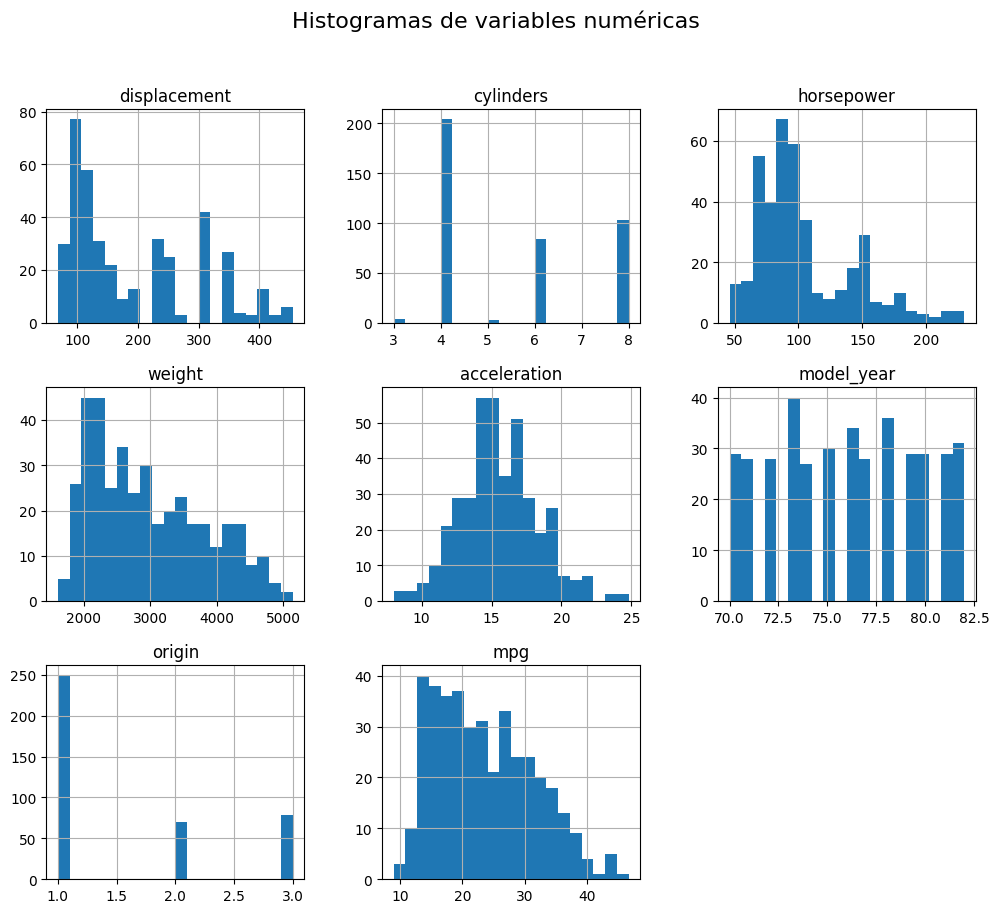

In [ ]:
df.hist(bins=20, figsize=(12,10))
plt.suptitle("Histogramas de variables numéricas", fontsize=16)
plt.show()

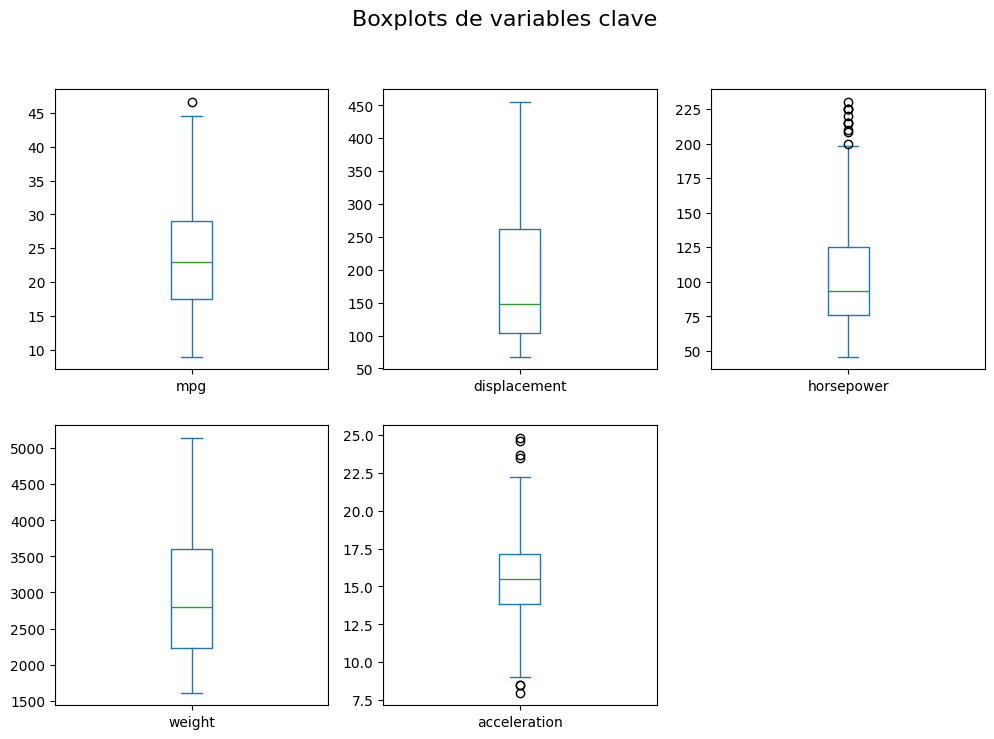

In [ ]:
df[["mpg","displacement","horsepower","weight","acceleration"]].plot(kind="box", subplots=True, layout=(2,3), figsize=(12,8))
plt.suptitle("Boxplots de variables clave", fontsize=16)
plt.show()

Análisis multivariado: Se genera una matriz de dispersión (scatter matrix) para visualizar las relaciones y correlaciones entre las principales variables numéricas y la variable objetivo 'mpg'.

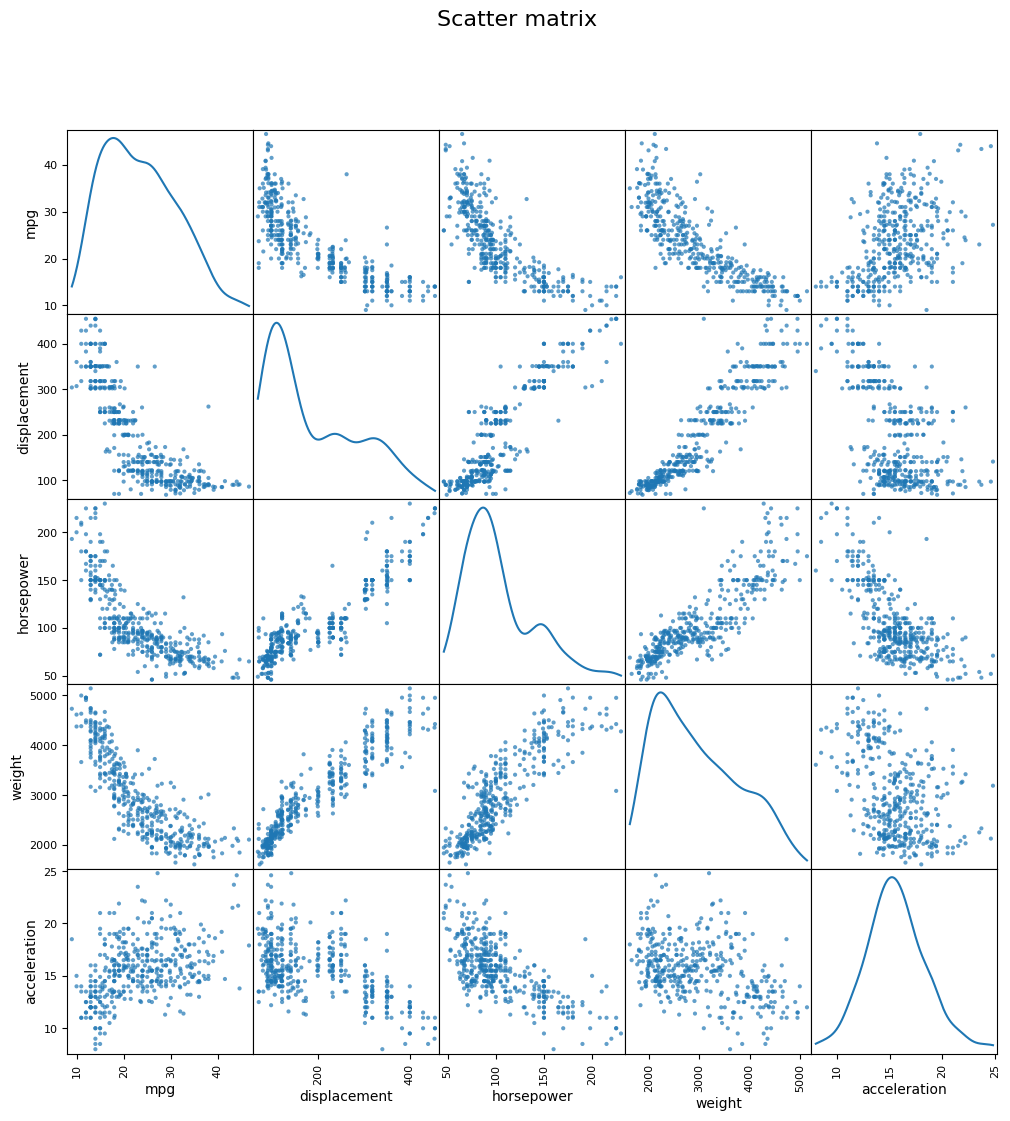

In [ ]:
  pd.plotting.scatter_matrix(df[["mpg","displacement","horsepower","weight","acceleration"]],
                            figsize=(12,12), diagonal="kde", alpha=0.7)
  plt.suptitle("Scatter matrix", fontsize=16)
  plt.show()

Detección de valores atípicos (Outliers): Se utiliza el método del rango intercuartílico (IQR) para identificar y contar la cantidad de outliers en cada una de las variables numéricas.

In [ ]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

outliers_count= {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1


    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    #contar outliers
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outliers_count[col] = len(outliers)

#mostrar conteo de outliers
outliers_count

{'displacement': 0,
 'cylinders': 0,
 'horsepower': 11,
 'weight': 0,
 'acceleration': 7,
 'model_year': 0,
 'origin': 0,
 'mpg': 1}

Análisis de correlación: Se visualiza una matriz de correlación con un mapa de calor para identificar las relaciones lineales entre las variables y detectar posible multicolinealidad.

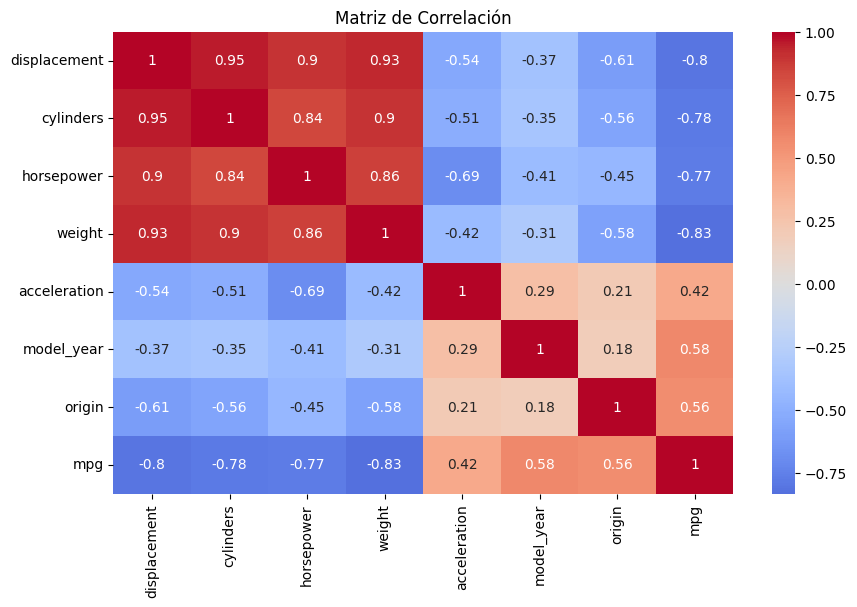

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title("Matriz de Correlación")
plt.show()

Análisis de la variable objetivo: Se grafica un histograma y una curva de densidad (KDE) de la columna 'mpg' para entender su distribución de frecuencias.

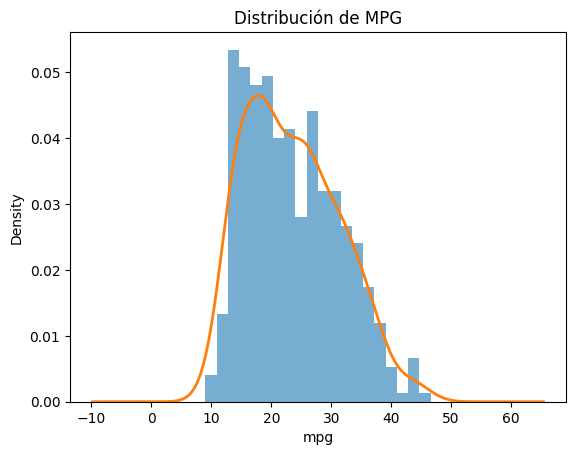

In [ ]:
df["mpg"].plot(kind="hist", bins=20, density=True, alpha=0.6)
df["mpg"].plot(kind="kde", linewidth=2)
plt.title("Distribución de MPG")
plt.xlabel("mpg")
plt.show()

Análisis de correlación con la variable objetivo: Se calcula la correlación de todas las variables numéricas con 'mpg' y se visualiza en un gráfico de barras para identificar rápidamente los predictores más influyentes.

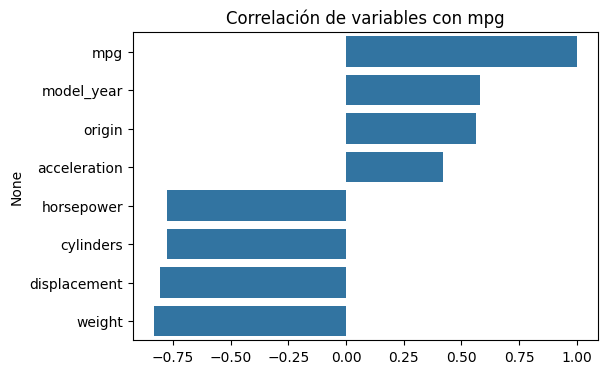

In [ ]:
corr = df.corr(numeric_only=True)
mpg_corr = corr["mpg"].sort_values(ascending=False)

plt.figure(figsize=(6,4))
sns.barplot(x=mpg_corr.values, y=mpg_corr.index)
plt.title("Correlación de variables con mpg")
plt.show()

Análisis de variables predictoras: Se generan histogramas para cada variable continua con el fin de visualizar sus distribuciones individuales y detectar posibles sesgos.

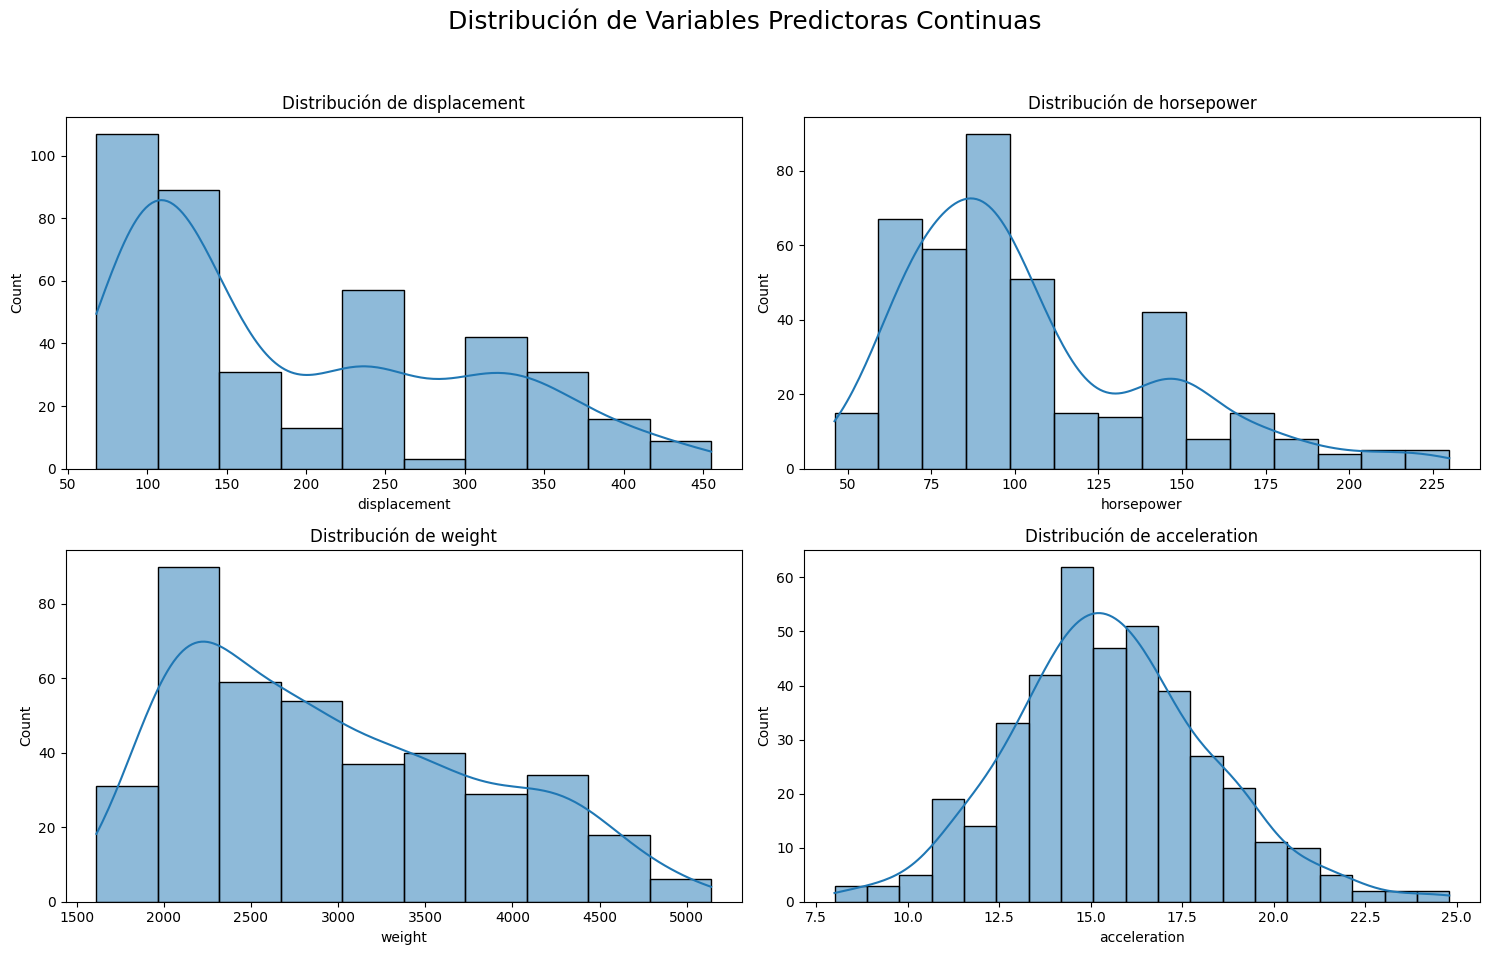

In [ ]:
# --- 3. Análisis de Variables Predictoras Continuas ---

continuous_vars = ['displacement', 'horsepower', 'weight', 'acceleration']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distribución de Variables Predictoras Continuas', fontsize=18)

for i, var in enumerate(continuous_vars):
    row, col = i // 2, i % 2
    sns.histplot(ax=axes[row, col], data=df, x=var, kde=True)
    axes[row, col].set_title(f'Distribución de {var}')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Variables Seleccionadas

Preparación para el modelado: Se seleccionan las variables predictoras (X) y la variable objetivo (y), y se divide el dataset en conjuntos de entrenamiento y prueba (80/20).

In [ ]:
# Variables predictoras y target
X = df[['horsepower','weight','acceleration','cylinders','displacement','origin','model_year']]
y = df['mpg']


# Dividir en train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Verificación de la división: Se imprimen las dimensiones de los conjuntos resultantes para confirmar que la división entre datos de entrenamiento y prueba se realizó correctamente.

In [ ]:
print("--- Dimensiones de los conjuntos de datos ---")
print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de y_train: {y_train.shape}")
print(f"Dimensiones de X_test:  {X_test.shape}")
print(f"Dimensiones de y_test:  {y_test.shape}")

total_samples = len(df)
train_samples = len(X_train)
test_samples = len(X_test)

print(f"\nTotal de muestras en el dataset original: {total_samples}")
print(f"Número de muestras de entrenamiento: {train_samples} ({train_samples/total_samples:.0%})")
print(f"Número de muestras de prueba: {test_samples} ({test_samples/total_samples:.0%})")

--- Dimensiones de los conjuntos de datos ---
Dimensiones de X_train: (318, 7)
Dimensiones de y_train: (318,)
Dimensiones de X_test:  (80, 7)
Dimensiones de y_test:  (80,)

Total de muestras en el dataset original: 398
Número de muestras de entrenamiento: 318 (80%)
Número de muestras de prueba: 80 (20%)


# Ecuación Normal

Estimación con Ecuación Normal (univariada): Se implementa la ecuación normal desde cero para calcular los parámetros de una regresión lineal simple (usando 'weight' como predictor) y se grafica la línea de ajuste resultante.

θ (parámetros):
[[ 4.67820634e+01]
 [-7.80524235e-03]]
Ecuación de la recta: ŷ = 46.78 + -0.01·x


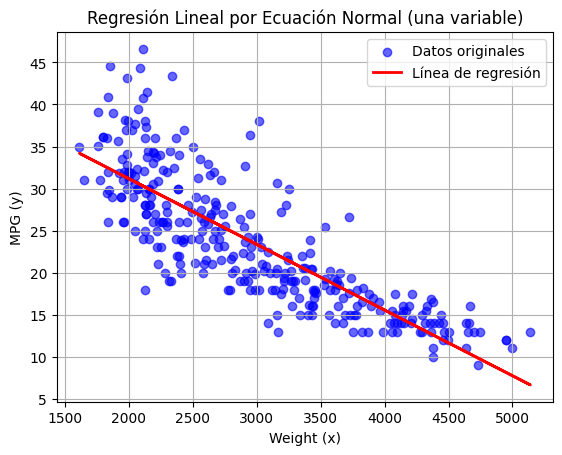

In [ ]:
## 4. Ecuación normal: θ = (X^T X)^(-1) X^T Y
# Para poder graficar, usamos solo una variable predictora (ej: 'weight')
x = X_train[['weight']].values   # feature como matriz (m,1)
y = y_train.values.reshape(-1,1) # target como vector columna

# 1) Agregar columna de 1s (intercepto)
X_b = np.c_[np.ones((x.shape[0], 1)), x]

# 2) Calcular parámetros θ = (X^T X)^(-1) X^T Y
XtX = X_b.T @ X_b
XtY = X_b.T @ y
theta = np.linalg.inv(XtX) @ XtY

# 3) Predicción: ŷ = θ0 + θ1 * x
y_pred = X_b @ theta

# 4) Mostrar resultados
print(f"θ (parámetros):\n{theta}")
print(f"Ecuación de la recta: ŷ = {theta[0,0]:.2f} + {theta[1,0]:.2f}·x")

# 5) Graficar ajuste
plt.scatter(x, y, color='blue', alpha=0.6, label='Datos originales')
plt.plot(x, y_pred, color='red', linewidth=2, label='Línea de regresión')
plt.xlabel('Weight (x)')
plt.ylabel('MPG (y)')
plt.title('Regresión Lineal por Ecuación Normal (una variable)')
plt.legend()
plt.grid(True)
plt.show()


Estimación y Evaluación con Ecuación Normal (multivariada): Se aplica la ecuación normal utilizando todas las variables predictoras seleccionadas y se calculan las métricas de rendimiento (MSE, R², RMSE) sobre el conjunto de prueba.

In [ ]:
# Agregar columna de 1's para el intercepto
X_train_np = np.c_[np.ones(X_train.shape[0]), X_train]
X_test_np = np.c_[np.ones(X_test.shape[0]), X_test]

# Cálculo de theta con ecuación normal
theta = np.linalg.inv(X_train_np.T.dot(X_train_np)).dot(X_train_np.T).dot(y_train)

# Predicciones
y_pred_normal = X_test_np.dot(theta)

# Métricas
print("Ecuación Normal:")
print("MSE:", mean_squared_error(y_test, y_pred_normal))
print("R2:", r2_score(y_test, y_pred_normal))
print("Theta:", theta)
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_normal)))

Ecuación Normal:
MSE: 8.197746885824108
R2: 0.8475304239212565
Theta: [-2.05593185e+01 -1.31871002e-02 -6.74637584e-03  6.87756673e-02
 -1.56793365e-01  1.42203442e-02  1.32295917e+00  7.94959578e-01]
RMSE: 2.863170774827116


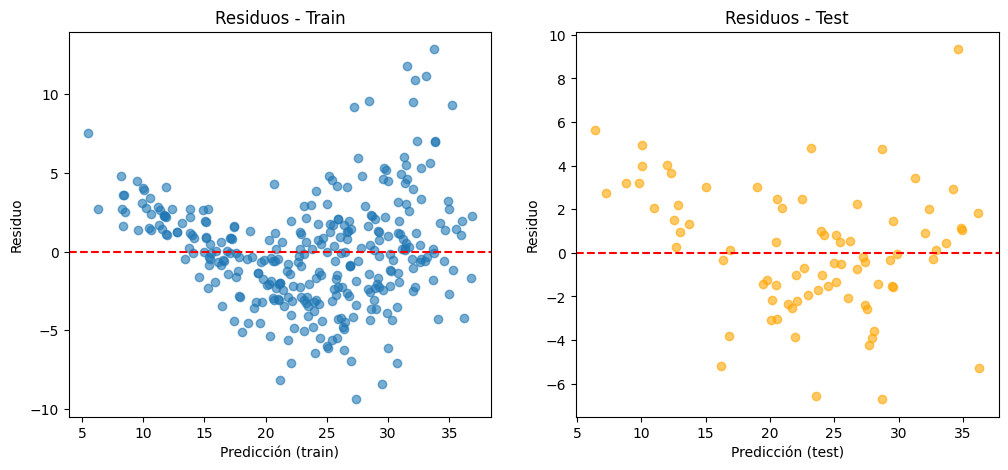

In [ ]:
y_train_pred = X_train_np.dot(theta)
y_test_pred = X_test_np.dot(theta)

# Residuos
res_train = y_train - y_train_pred
res_test = y_test - y_test_pred
plt.figure(figsize=(12,5))

# Train
plt.subplot(1,2,1)
plt.scatter(y_train_pred, res_train, alpha=0.6)
plt.axhline(0, color='r', linestyle='--')
plt.title("Residuos - Train")
plt.xlabel("Predicción (train)")
plt.ylabel("Residuo")

# Test
plt.subplot(1,2,2)
plt.scatter(y_test_pred, res_test, alpha=0.6, color="orange")
plt.axhline(0, color='r', linestyle='--')
plt.title("Residuos - Test")
plt.xlabel("Predicción (test)")
plt.ylabel("Residuo")

plt.show()


# Scikit-learn:

Definición de Pipeline de Preprocesamiento: Se crea un pipeline para automatizar la preparación de datos, incluyendo la imputación de valores nulos, el escalado de variables numéricas y la codificación (One-Hot) de variables categóricas.|

In [ ]:
y = df["mpg"].values # Variable objetivo
X = df.drop(columns=["mpg"])

# Columnas numéricas y categóricas
num_cols = ["cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year"]
cat_cols = ["origin"]  # la vamos a codificar

# Pipeline para numéricas (imputar + escalar)
numeric_pipe = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("sc",  StandardScaler())
])

# Pipeline para categóricas (OneHot)
categorical_pipe = Pipeline([
    ("imp", SimpleImputer(strategy="most_frequent")),  # por si acaso hay NaN
    ("oh", OneHotEncoder(drop="first"))  # drop="first" evita colinealidad
])

# Preprocesador general
preprocessor = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
])

Creación de Función para Reporte de Métricas: Se define una función auxiliar para calcular y mostrar de manera estandarizada las métricas de evaluación (MSE, RMSE y R²) de los modelos.

In [ ]:
# métricas
def report(y_true, y_pred, nombre):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = mse**0.5
    r2   = r2_score(y_true, y_pred)
    print(f"{nombre} -> MSE: {mse:.3f} | RMSE: {rmse:.3f} | R²: {r2:.3f}")

## Regresión lineal estándar.

Modelo de Regresión Lineal Estándar: Se entrena un modelo de regresión lineal utilizando el pipeline de preprocesamiento y se evalúa su rendimiento en los conjuntos de entrenamiento y prueba.

In [ ]:
ols = Pipeline([
    ("prep", preprocessor),
    ("model", LinearRegression())
])
ols.fit(X_train, y_train)

report(y_train, ols.predict(X_train), "OLS (sklearn) - Train")
report(y_test,   ols.predict(X_test),   "OLS (sklearn) - Val")

OLS (sklearn) - Train -> MSE: 11.355 | RMSE: 3.370 | R²: 0.819
OLS (sklearn) - Val -> MSE: 8.339 | RMSE: 2.888 | R²: 0.845


se presento el fenómeno de sobreajuste en el modelo entrenado?

Análisis de Residuos: Se grafican los residuos (diferencia entre valores reales y predichos) para los conjuntos de entrenamiento y prueba, con el fin de verificar la homocedasticidad y detectar patrones no capturados por el modelo.

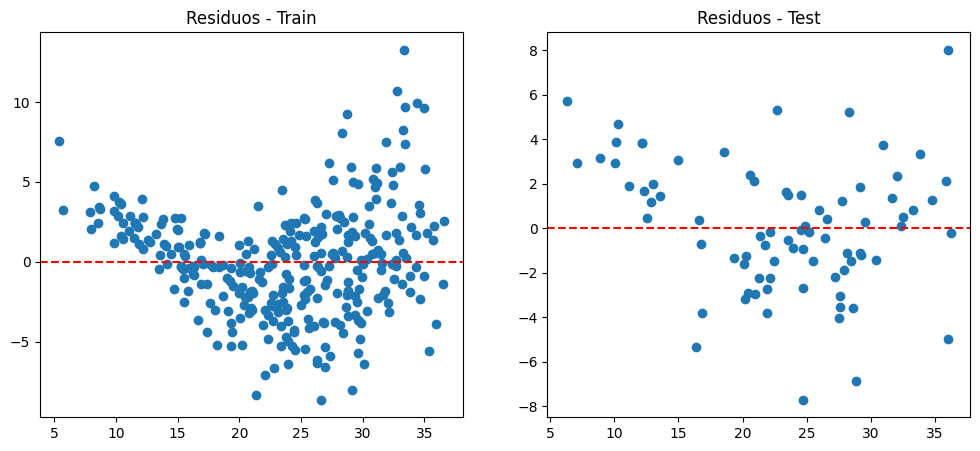

In [ ]:
res_train = y_train - ols.predict(X_train)
res_test = y_test - ols.predict(X_test)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(ols.predict(X_train), res_train)
plt.axhline(0, color='r', linestyle='--')
plt.title("Residuos - Train")

plt.subplot(1,2,2)
plt.scatter(ols.predict(X_test), res_test)
plt.axhline(0, color='r', linestyle='--')
plt.title("Residuos - Test")
plt.show()


No parece haber sobreajuste evidente. Si hubiera overfitting:

- Los residuos en entrenamiento serían muy pequeños o cercanos a cero

- Los residuos en validación serían mucho más grandes y con patrones sistemáticos.

En los gráficos vemos como ambos conjuntos muestran dispersión comparable y no hay indicios de que el modelo esté memorizando los datos

## Con regularización Lasso

Modelo de Regresión Lasso: Se entrena un modelo Lasso con validación cruzada (`GridSearchCV`) para encontrar el hiperparámetro de regularización (alpha) óptimo, y se evalúa el rendimiento del mejor modelo.

In [ ]:
lasso = Pipeline([
    ("prep", preprocessor),
    ("model", Lasso(max_iter=10000, random_state=42))
])

param_lasso = {"model__alpha": [0.001, 0.01, 0.1, 1, 10]}
lasso_cv = GridSearchCV(lasso, param_grid=param_lasso, cv=5, scoring="neg_mean_squared_error")
lasso_cv.fit(X_train, y_train)

best_lasso = lasso_cv.best_estimator_
print("Mejor alpha Lasso:", lasso_cv.best_params_)

report(y_train, best_lasso.predict(X_train), "Lasso - Train")
report(y_test,   best_lasso.predict(X_test),   "Lasso - Val")

Mejor alpha Lasso: {'model__alpha': 0.01}
Lasso - Train -> MSE: 11.371 | RMSE: 3.372 | R²: 0.819
Lasso - Val -> MSE: 8.433 | RMSE: 2.904 | R²: 0.843


Análisis de Residuos (Lasso): Se grafican los residuos del modelo Lasso para verificar la distribución de los errores y asegurar que no existen patrones sistemáticos.

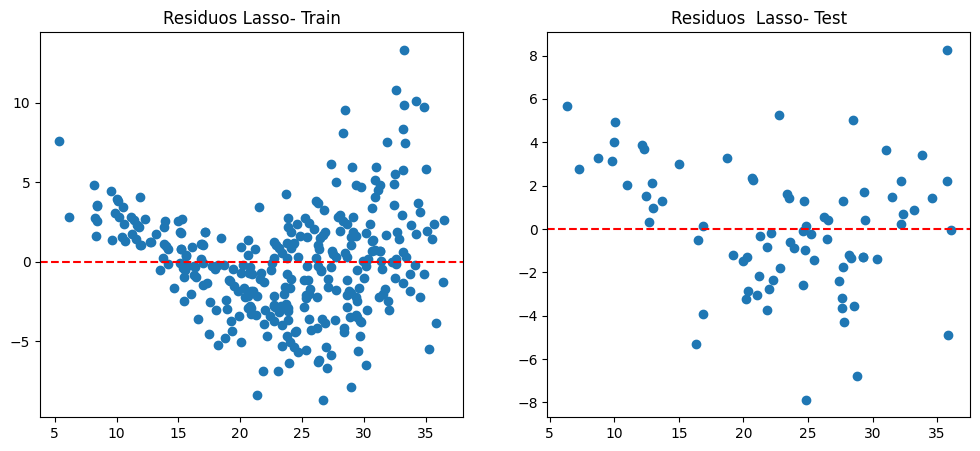

In [ ]:
res_train = y_train - best_lasso.predict(X_train)
res_test = y_test - best_lasso.predict(X_test)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(best_lasso.predict(X_train), res_train)
plt.axhline(0, color='r', linestyle='--')
plt.title("Residuos Lasso- Train")

plt.subplot(1,2,2)
plt.scatter(best_lasso.predict(X_test), res_test)
plt.axhline(0, color='r', linestyle='--')
plt.title("Residuos  Lasso- Test")
plt.show()


## Con regularización Ridge

Modelo de Regresión Ridge: Se entrena un modelo Ridge con validación cruzada (`GridSearchCV`) para determinar el mejor valor de alpha, evaluando posteriormente el rendimiento del modelo optimizado.

In [ ]:
ridge = Pipeline([
    ("prep", preprocessor),
    ("model", Ridge(random_state=42))
])

param_ridge = {"model__alpha": [0.001, 0.01, 0.1, 1, 10, 100]}
ridge_cv = GridSearchCV(ridge, param_grid=param_ridge, cv=5, scoring="neg_mean_squared_error")
ridge_cv.fit(X_train, y_train)

best_ridge = ridge_cv.best_estimator_
print("Mejor alpha Ridge:", ridge_cv.best_params_)

report(y_train, best_ridge.predict(X_train), "Ridge - Train")
report(y_test,   best_ridge.predict(X_test),   "Ridge - Val")

Mejor alpha Ridge: {'model__alpha': 1}
Ridge - Train -> MSE: 11.364 | RMSE: 3.371 | R²: 0.819
Ridge - Val -> MSE: 8.348 | RMSE: 2.889 | R²: 0.845


Análisis de Residuos (Ridge): Se visualizan los residuos del modelo Ridge para los conjuntos de entrenamiento y prueba, confirmando que los errores se distribuyen de manera aleatoria alrededor de cero.

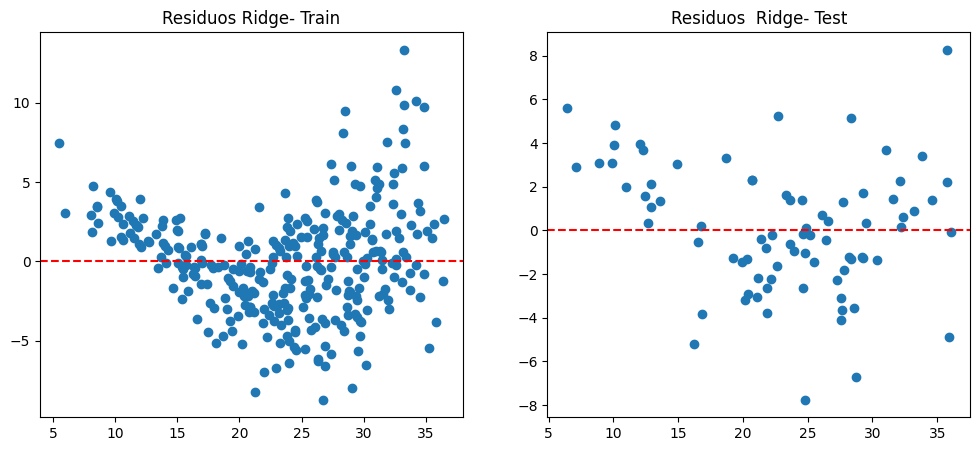

In [ ]:
res_train = y_train - best_ridge.predict(X_train)
res_test = y_test - best_ridge.predict(X_test)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(best_ridge.predict(X_train), res_train)
plt.axhline(0, color='r', linestyle='--')
plt.title("Residuos Ridge- Train")

plt.subplot(1,2,2)
plt.scatter(best_ridge.predict(X_test), res_test)
plt.axhline(0, color='r', linestyle='--')
plt.title("Residuos  Ridge- Test")
plt.show()

# Gradiente descendente

Estimación con Gradiente Descendente: Se implementa el algoritmo de gradiente descendente desde cero, escalando primero los datos. Luego, se entrena el modelo de forma iterativa y se calculan sus métricas de rendimiento.

In [ ]:

# Escalado
scaler = StandardScaler()
X_train_gd = scaler.fit_transform(X_train)
X_test_gd = scaler.transform(X_test)

# Añadir columna de 1's para intercepto
X_train_gd = np.c_[np.ones((X_train_gd.shape[0], 1)), X_train_gd]
X_test_gd = np.c_[np.ones((X_test_gd.shape[0], 1)), X_test_gd]

# Convertir y a numpy
y_train = y_train.values
y_test = y_test.values

# Parámetros iniciales
m, n = X_train_gd.shape
theta = np.zeros(n)
alpha = 0.01
epochs = 1000
cost_history = []

# Gradiente descendente
for i in range(epochs):
    predictions = X_train_gd.dot(theta)
    errors = predictions - y_train
    gradients = (1/m) * X_train_gd.T.dot(errors)
    theta -= alpha * gradients
    cost = (1/(2*m)) * np.sum(errors**2)
    cost_history.append(cost)

# Predicciones
y_pred_gd = X_test_gd.dot(theta)
# --- Métricas ---
mse = mean_squared_error(y_test, y_pred_gd)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_gd)

print("Gradiente Descendente:")
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)
print("Coeficientes (theta):", theta)

Gradiente Descendente:
MSE: 8.716237306408308
RMSE: 2.952327438887548
R²: 0.837887040717505
Coeficientes (theta): [23.60715691 -1.11341401 -3.58925681 -0.33746746 -0.25539826 -0.3633445
  1.01637755  2.69512141]


Visualización de la Convergencia: Se grafica la función de costo a lo largo de las iteraciones para verificar que el algoritmo de gradiente descendente ha convergido correctamente hacia un mínimo.

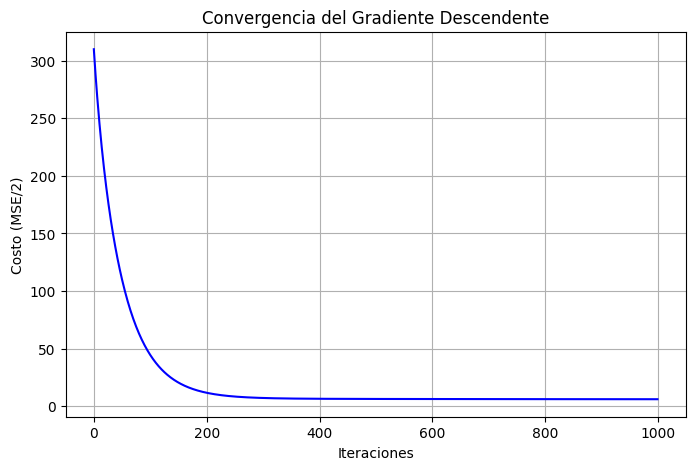

In [ ]:
# --- Gráfica de convergencia ---
plt.figure(figsize=(8,5))
plt.plot(range(epochs), cost_history, color="blue")
plt.title("Convergencia del Gradiente Descendente")
plt.xlabel("Iteraciones")
plt.ylabel("Costo (MSE/2)")
plt.grid(True)
plt.show()

# Responder las siguientes preguntas :

### ¿Es posible que se presente el fenómeno de sobreajuste (overfitting) en la regresión lineal?

Sí, es posible que se presente el *sobreajuste (overfitting)* en un modelo de regresión lineal, especialmente cuando se trabaja con modelos polinomiales de alto grado o cuando se incluyen demasiadas variables irrelevantes en el análisis. El sobreajuste ocurre cuando el modelo “aprende de memoria” los datos de entrenamiento, logrando un error muy bajo en este conjunto, pero mostrando un rendimiento pobre en los datos de prueba.

Para detectar este fenómeno, se comparan los errores de entrenamiento y prueba (por ejemplo, con métricas como el RMSE o el R²).

- *Si el error en entrenamiento es mucho menor que en prueba → existe sobreajuste.*
- *Si ambos errores son similares y bajos → el modelo generaliza bien*

### ¿Se presento el fenómeno de sobreajuste en el modelo entrenado?

No, no parece haber sobreajuste evidente. Si hubiera overfitting:

- Los residuos en entrenamiento serían muy pequeños o cercanos a cero (modelo “memorizó” los datos).

- Los residuos en validación serían mucho más grandes y con patrones sistemáticos.

Como vimos en los graficos, ambos conjuntos (train y val) muestran dispersión comparable y no hay indicios de que el modelo presente overfitting

### ¿El data set seleccionado presenta valores atípicos (outliers)? ¿Cómo se identificaron los valores atípicos?

Sí, el dataset **Auto MPG** presenta valores atípicos. Durante el análisis exploratorio de datos (EDA) se identificaron observaciones que se alejan significativamente del comportamiento general de las variables.


Los outliers se detectaron utilizando diferentes técnicas:

1. **Método estadístico con el rango intercuartílico (IQR):**
    - Se calcularon los cuartiles Q1 (25%) y Q3 (75%), y a partir de ellos el rango intercuartílico (IQR = Q3 - Q1).
    - Se consideraron como outliers los valores que estaban por debajo de Q1 - 1.5*IQR o por encima de Q3 + 1.5*IQR.
    - Esto permitió identificar valores extremos, por ejemplo en las variables **`mpg` (millas por galón)** y **`horsepower` (caballos de fuerza)**.
2. **Gráficos de dispersión y boxplots:**
    - Los **boxplots** mostraron puntos individuales alejados de la caja, lo que indicó la presencia de valores atípicos.
    - En los **scatter plots**, especialmente entre `mpg` y `weight`, se observaron autos con combinaciones poco comunes (por ejemplo, vehículos muy pesados con alto consumo de combustible).
3. **Histogramas y curvas de densidad:**
    - Algunas variables mostraron colas largas (asimetría), confirmando la existencia de valores atípicos en la parte superior de la distribución.

### ¿Es necesario eliminar los valores atípicos (outliers)? ¿Por qué sí o por qué no?
No siempre es necesario eliminar los outliers.

- *Se deben eliminar* si se demuestra que corresponden a errores en la recolección, digitación o medición de datos.
- *Se deben mantener* si representan casos reales y válidos, aunque poco frecuentes.

En muchos casos, es más recomendable *probar el modelo con y sin outliers* y comparar resultados. También existen alternativas como *transformaciones matemáticas* (logaritmo, raíz cuadrada), *winsorización* (recortar extremos), o el uso de *modelos robustos* (como RANSAC o regresión robusta).

Por lo tanto, la decisión de eliminarlos dependerá de si afectan la calidad del modelo y de la naturaleza de los datos.

### ¿Qué es el escalado (Normalization)? ¿Cuándo es necesario?
El *escalado (o normalización/estandarización)* es el proceso de transformar las variables para que tengan la *misma escala* y no dominen unas sobre otras debido a sus unidades o rangos.

Los dos métodos más usados son:

- *Normalización Min–Max:* convierte los valores a un rango \[0,1].
- *Estandarización:* transforma los datos para que tengan media 0 y desviación estándar 1.

El escalado es *necesario* cuando:

- Las variables están en *unidades muy distintas* (por ejemplo, kilómetros y litros).
- Se usan algoritmos sensibles a la escala: *Descenso de Gradiente, kNN, SVM, Redes Neuronales, PCA, y cuando se aplica **regularización* (Ridge o Lasso).

En regresión lineal con la Ecuación Normal, no siempre es obligatorio, pero en Descenso de Gradiente sí mejora mucho la convergencia.

### ¿En qué escenario es preferible utilizar el Descenso del Gradiente en lugar de la Regresión Ordinaria por Mínimos Cuadrados (Ecuación Normal) y por qué?

El *Descenso del Gradiente* es preferible en los siguientes escenarios:

1. *Cuando el dataset es muy grande* (con millones de filas o muchas variables). La Ecuación Normal requiere invertir una matriz de tamaño n×n (siendo n el número de características), lo que es computacionalmente costoso.
2. *Cuando los datos llegan en tiempo real o en lotes pequeños (mini-batch/online learning).*
3. *Cuando se desea incluir regularización (Ridge o Lasso).* El Descenso del Gradiente permite agregar penalizaciones fácilmente.
4. *Cuando hay multicolinealidad*, la Ecuación Normal puede ser inestable, mientras que el Descenso del Gradiente no depende de invertir matrices.

Por lo tanto, *el Descenso del Gradiente es más eficiente y escalable* en escenarios con gran cantidad de datos o donde se necesita un ajuste dinámico y regularizado.

La *Ecuación Normal* se usa principalmente cuando el conjunto de datos es *pequeño o de tamaño medio* y cuando el número de características no es muy grande. Es útil porque entrega una *solución exacta y directa*, sin necesidad de elegir parámetros como la tasa de aprendizaje.

Se utiliza en los siguientes casos:

- *Datasets pequeños o medianos* (pocas variables y registros).
- *Cuando se busca rapidez en el cálculo* y no se planea entrenar el modelo muchas veces.
- *Cuando no es necesario el procesamiento en línea o en lotes* (se tiene todo el dataset de una sola vez).
- *Cuando se prefiere exactitud sobre eficiencia computacional*, ya que la Ecuación Normal da la solución cerrada del modelo.

En resumen, la *Ecuación Normal* es ideal en *problemas sencillos y con pocos datos, mientras que el **Descenso del Gradiente* es la mejor opción en datasets grandes o con necesidad de regularización.